<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/simulation/v_kernel_multicore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
NUM_NODES = 60
CONNECTION_PROB = 0.1
NOISE_LEVEL = 0.4
PRUNE_THRESHOLD = 0.2
ITERATIONS = 30

NUM_BINDU = 3

In [3]:
G = nx.DiGraph()

for i in range(NUM_NODES):
    G.add_node(i, value=random.uniform(-1, 1))

for i in range(NUM_NODES):
    for j in range(NUM_NODES):
        if i != j and random.random() < CONNECTION_PROB:
            G.add_edge(i, j, weight=random.uniform(0.1, 1.0))

In [4]:
def add_noise(G):
    for n in G.nodes:
        G.nodes[n]["value"] += random.uniform(-NOISE_LEVEL, NOISE_LEVEL)

def forward_pass(G):
    new_values = {}
    for n in G.nodes:
        total = 0
        for pred in G.predecessors(n):
            total += G.nodes[pred]["value"] * G[pred][n]["weight"]
        new_values[n] = total
    return new_values

def normalize(G, new_values):
    total = sum(abs(v) for v in new_values.values()) + 1e-6
    for n in G.nodes:
        G.nodes[n]["value"] = new_values[n] / total

def reinforce(G):
    for u, v in G.edges:
        G[u][v]["weight"] *= random.uniform(0.95, 1.1)

def decay(G):
    for u, v in G.edges:
        G[u][v]["weight"] *= 0.94

def prune(G):
    to_remove = []
    for u, v in G.edges:
        if abs(G[u][v]["weight"]) < PRUNE_THRESHOLD:
            to_remove.append((u, v))
    for e in to_remove:
        G.remove_edge(*e)
    return len(to_remove)

def coherence(G):
    vals = [G.nodes[n]["value"] for n in G.nodes]
    mean = sum(vals) / len(vals)
    var = sum((v - mean)**2 for v in vals) / len(vals)
    return 1 / (1 + var)

In [5]:
def detect_multiple_bindu(G, k=3):
    centrality = nx.degree_centrality(G)
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)
    return [n for n, _ in sorted_nodes[:k]]

In [6]:
def draw_graph(G, step, coh):
    plt.figure(figsize=(6,6))
    pos = nx.spring_layout(G, seed=42)

    bindus = detect_multiple_bindu(G, NUM_BINDU)

    colors = []
    sizes = []

    for n in G.nodes:
        v = G.nodes[n]["value"]

        if v > 0:
            colors.append((1-v, 0.2, v))
        else:
            colors.append((abs(v), 0.2, 1-abs(v)))

        if n in bindus:
            sizes.append(400)
        else:
            sizes.append(100)

    nx.draw(G, pos,
            node_color=colors,
            node_size=sizes,
            edge_color="gray",
            alpha=0.8)

    plt.title(f"Step {step} | Coherence {coh:.3f} | Bindu: {bindus}")
    plt.show()

=== MULTI-BINDU SIMULATION ===
[STEP 0] coherence=0.9996 bindus=[48, 50, 11] pruned=42


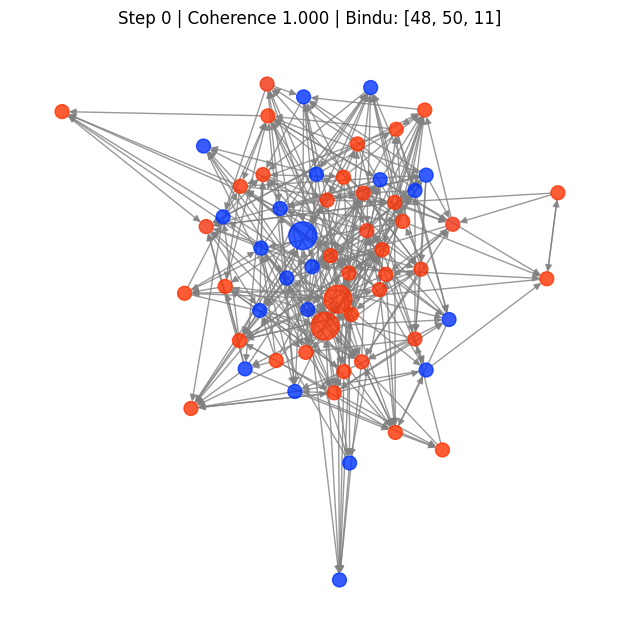

[STEP 1] coherence=0.9996 bindus=[48, 50, 18] pruned=4
[STEP 2] coherence=0.9996 bindus=[48, 50, 18] pruned=3
[STEP 3] coherence=0.9996 bindus=[48, 50, 18] pruned=3
[STEP 4] coherence=0.9997 bindus=[48, 50, 18] pruned=4
[STEP 5] coherence=0.9996 bindus=[48, 50, 56] pruned=1


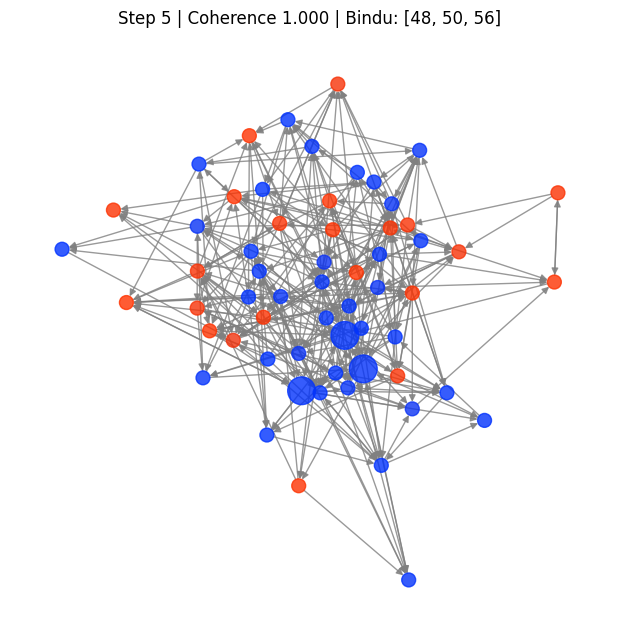

[STEP 6] coherence=0.9996 bindus=[48, 50, 56] pruned=1
[STEP 7] coherence=0.9996 bindus=[48, 50, 56] pruned=2
[STEP 8] coherence=0.9996 bindus=[48, 50, 18] pruned=3
[STEP 9] coherence=0.9998 bindus=[48, 50, 18] pruned=1
[STEP 10] coherence=0.9996 bindus=[48, 50, 18] pruned=3


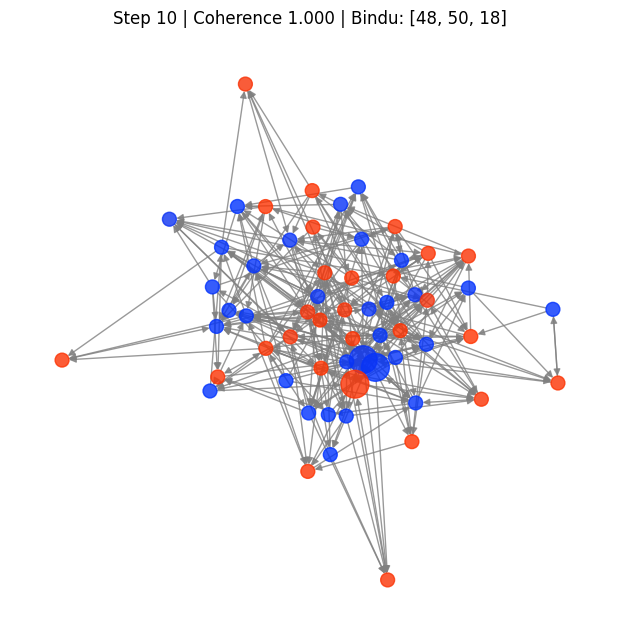

[STEP 11] coherence=0.9995 bindus=[48, 50, 18] pruned=6
[STEP 12] coherence=0.9997 bindus=[48, 50, 18] pruned=2
[STEP 13] coherence=0.9996 bindus=[48, 50, 37] pruned=11
[STEP 14] coherence=0.9995 bindus=[48, 50, 37] pruned=0
[STEP 15] coherence=0.9996 bindus=[48, 50, 37] pruned=3


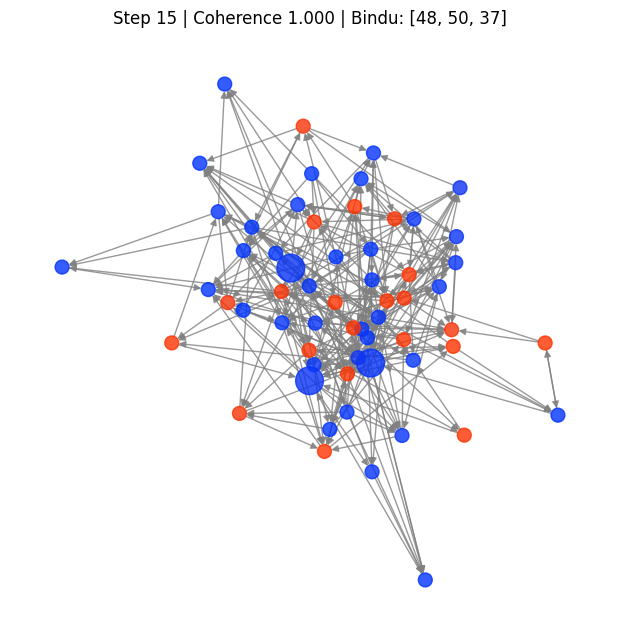

[STEP 16] coherence=0.9996 bindus=[48, 50, 37] pruned=8
[STEP 17] coherence=0.9996 bindus=[48, 50, 37] pruned=10
[STEP 18] coherence=0.9996 bindus=[48, 50, 37] pruned=12
[STEP 19] coherence=0.9997 bindus=[48, 50, 22] pruned=6
[STEP 20] coherence=0.9995 bindus=[48, 50, 22] pruned=11


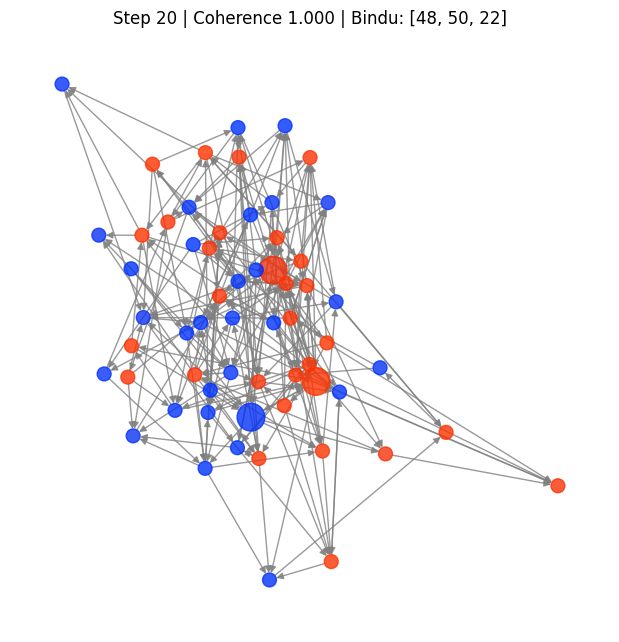

[STEP 21] coherence=0.9997 bindus=[48, 50, 22] pruned=9
[STEP 22] coherence=0.9996 bindus=[48, 50, 22] pruned=7
[STEP 23] coherence=0.9996 bindus=[48, 50, 22] pruned=8
[STEP 24] coherence=0.9996 bindus=[48, 22, 50] pruned=12
[STEP 25] coherence=0.9996 bindus=[48, 11, 22] pruned=4


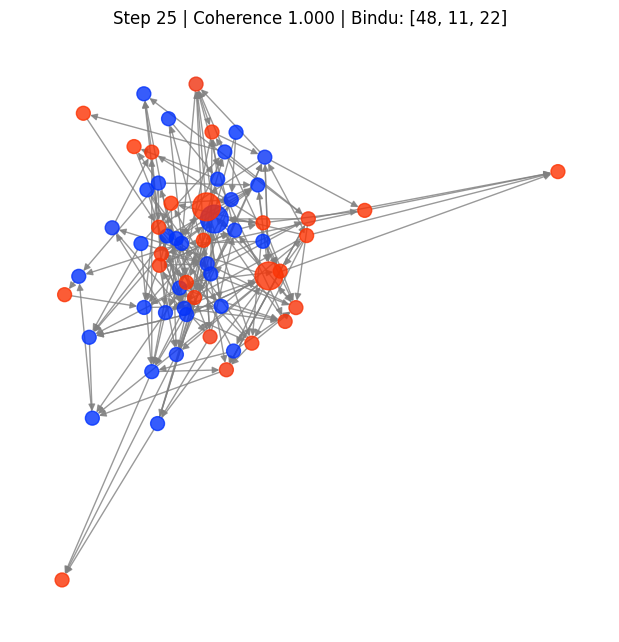

[STEP 26] coherence=0.9995 bindus=[48, 11, 33] pruned=11
[STEP 27] coherence=0.9995 bindus=[48, 11, 33] pruned=9
[STEP 28] coherence=0.9996 bindus=[48, 11, 18] pruned=6
[STEP 29] coherence=0.9995 bindus=[48, 11, 18] pruned=8
=== END ===


In [7]:
print("=== MULTI-BINDU SIMULATION ===")

for step in range(ITERATIONS):

    add_noise(G)
    new_vals = forward_pass(G)
    normalize(G, new_vals)

    reinforce(G)
    decay(G)

    removed = prune(G)
    coh = coherence(G)

    bindus = detect_multiple_bindu(G, NUM_BINDU)

    print(f"[STEP {step}] coherence={coh:.4f} bindus={bindus} pruned={removed}")

    if step % 5 == 0:
        draw_graph(G, step, coh)

print("=== END ===")